# Surface area + roughness factor calculations
This notebook includes back of the envelope calculations to determine the roughness factor that would be needed to achieve a gross CDR flux of 8.3 tCO2e/ha/yr.

This rough analysis is conservative (lower-bound) in three ways:
1. It assumes no change in soil water chemistry with progressive dissolution (i.e., no increase in pH or saturation)
2. It assumes a constant rock surface area, which must be a bad assumption because ~63% of the rock mass must have weathered congruently to hit the claimed CDR (assuming 0.3 tCDR/tRock).
3. It assumes congruent weathering with 100% CDR efficiency

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import xarray as xr 

# -----------------------------
# inputs 
# 
# field application
rock_applied_t_per_ha = 43.4          # tonnes basalt per hectare (derived from validation and verification report: https://puro.earth/documents/content/GmA-e4rASteUvTUJP7GC7Qo2982?download=0)
cdr_claim_t_per_ha = 8.3              # tonnes CO2 per hectare in ~1 year (derived from validation and verification report: https://puro.earth/documents/content/GmA-e4rASteUvTUJP7GC7Qo2982?download=0; this is a lower-bound -- assuming rock was spread June 21, 2024 and reporting ended June 2, 2025, would give us 8.8 t/ha/yr)
cdr_potential_t_per_t = 0.3           # tonnes CO2 per tonne basalt (e.g., Renforth, 2012 10.1016/j.ijggc.2012.06.011; Lewis et al. 2021 10.1016/j.apgeochem.2021.105023; Strefler et al. 2018 10.1088/1748-9326/aaa9c4; Holden et al. 2024 10.1016/j.scitotenv.2024.176568; Rinder and von Hagke, 2021 10.1016/j.jclepro.2021.128178;)
#
# grain properties
# (lithos claimed p90 is 990 um (project description, table 3.1, https://puro.earth/documents/content/FL9msA_5QsKmBgZH5SffHAo2984?download=0), so use that as an upper-bound)
grain_diameter_eff = np.linspace(10,990, 100) * 1e-6 # [m] lithos claimed p90 is 990 for WI/MI sites
basalt_density = 3000.0               # kg m^-3

# basalt chemistry + diss
molar_mass_basalt = 0.125             # [kg/mol] Strefler et al. 2018 10.1088/1748-9326/aaa9c4
# pH-dependent dissolution rate
log_diss_rate = np.linspace(-9,-13, 100) # [mol m^-2 s^-1] range of dissolution rates to test (Strefler et al. 2018 10.1088/1748-9326/aaa9c4; Oelkers et al. 2018 10.1016/j.chemgeo.2018.10.008; Renforth et al. 2015 10.1016/j.apgeochem.2015.05.016; Pogge von Strandmann et al. 2022 10.3389/fclim.2022.827698)
rate = 10 ** log_diss_rate          # [mol m^-2 s^-1]

# time
seconds_per_year = 365.25 * 24 * 3600

# ---------------------------------
# set up 2D coordinates
# 
rate_2d, diam_2d = np.meshgrid(rate, grain_diameter_eff, indexing="ij")

# compute geometric surface area on 2D grid
surface_area_per_kg_2d = 6.0 / (basalt_density * diam_2d)     # derived from equations for area and volume of sphere
geometric_surface_area_2d = rock_applied_t_per_ha * 1e3 * surface_area_per_kg_2d    # [m2 ha-1] surface area (m2) per hectare of land (convert from t to kg)

# ---------------------------------
# geom. SA expected dissolution
# 
moles_dissolved_geom = (
    geometric_surface_area_2d * rate_2d * seconds_per_year  # [mol ha-1]
)

basalt_dissolved_geom_kg = moles_dissolved_geom * molar_mass_basalt # [kg ha-1]
basalt_dissolved_geom_t = basalt_dissolved_geom_kg / 1e3    # [t ha-1]

cdr_expected_t_per_ha = basalt_dissolved_geom_t * cdr_potential_t_per_t

# ---------------------------------
# roughness factor for claimed diss
# 
basalt_required_t = cdr_claim_t_per_ha / cdr_potential_t_per_t   # [t ha-1] basalt required to dissolve to achieve claimed CDR
basalt_required_kg = basalt_required_t * 1e3        # [kg ha-1]
moles_required = basalt_required_kg / molar_mass_basalt    # [mol ha-1] moles of basalt required to dissolve to achieve claimed CDR

required_surface_area = (
    moles_required / (rate_2d * seconds_per_year)    # [m2 ha-1] surface area required to achieve claimed CDR given dissolution rate
)

roughness_factor = required_surface_area / geometric_surface_area_2d  # [] roughness factor required to achieve claimed CDR given geometric surface area and dissolution rate

# ---------------------------------
# package into xarray Dataset
# ---------------------------------
ds = xr.Dataset(
    data_vars=dict(
        geometric_surface_area=(
            ("rate", "diameter_um"),
            geometric_surface_area_2d,
        ),
        moles_dissolved_geom=(
            ("rate", "diameter_um"),
            moles_dissolved_geom,
        ),
        basalt_dissolved_geom_t=(
            ("rate", "diameter_um"),
            basalt_dissolved_geom_t,
        ),
        cdr_expected_t_per_ha=(
            ("rate", "diameter_um"),
            cdr_expected_t_per_ha,
        ),
        roughness_factor=(
            ("rate", "diameter_um"),
            roughness_factor,
        ),
    ),
    coords=dict(
        rate=("rate", rate),
        log_diss_rate=("rate", log_diss_rate),
        diameter_um=("diameter_um", grain_diameter_eff*1e6),
    ),
    attrs=dict(
        description="Basalt weathering and CDR estimates over rate and effective grain diameter",
        basalt_density="kg m-3",
        molar_mass_basalt="kg mol-1",
    ),
)
# add SSA
ds['grain_volume_m3'] = (4/3) * np.pi * (ds['diameter_um']*1e-6 / 2)**3    # [m3]
ds['grain_mass'] = ds['grain_volume_m3'] * (basalt_density * 1e3)   # [g] (convert density from kg to g)
ds['grain_geom_sa'] = 4 * np.pi * (ds['diameter_um']*1e-6 / 2)**2  # [m2] geometric surface area of a single grain
ds['geometric_ssa'] = ds['grain_geom_sa'] / ds['grain_mass']  # [m2/g]
ds['ssa'] = ds['geometric_ssa'] * ds['roughness_factor']
ds

<xarray.Dataset> Size: 486kB
Dimensions:                  (rate: 100, diameter_um: 100)
Coordinates:
  * rate                     (rate) float64 800B 1e-09 9.112e-10 ... 1e-13
    log_diss_rate            (rate) float64 800B -9.0 -9.04 ... -12.96 -13.0
  * diameter_um              (diameter_um) float64 800B 10.0 19.9 ... 990.0
Data variables:
    geometric_surface_area   (rate, diameter_um) float64 80kB 8.68e+06 ... 8....
    moles_dissolved_geom     (rate, diameter_um) float64 80kB 2.739e+05 ... 0...
    basalt_dissolved_geom_t  (rate, diameter_um) float64 80kB 34.24 ... 3.459...
    cdr_expected_t_per_ha    (rate, diameter_um) float64 80kB 10.27 ... 1.038...
    roughness_factor         (rate, diameter_um) float64 80kB 0.808 ... 7.999...
    grain_volume_m3          (diameter_um) float64 800B 5.236e-16 ... 5.08e-10
    grain_mass               (diameter_um) float64 800B 1.571e-09 ... 0.001524
    grain_geom_sa            (diameter_um) float64 800B 3.142e-10 ... 3.079e-06
    geometric_ssa            (diameter_um) float64 800B 0.2 0.1005 ... 0.00202
    ssa                      (diameter_um, rate) float64 80kB 0.1616 ... 1.61...
Attributes:
    description:        Basalt weathering and CDR estimates over rate and eff...
    basalt_density:     kg m-3
    molar_mass_basalt:  kg mol-1

## Rate versus roughness factor
Plot the weathering rate (X) versus the roughness factor (Y) for a given set of grain diameters

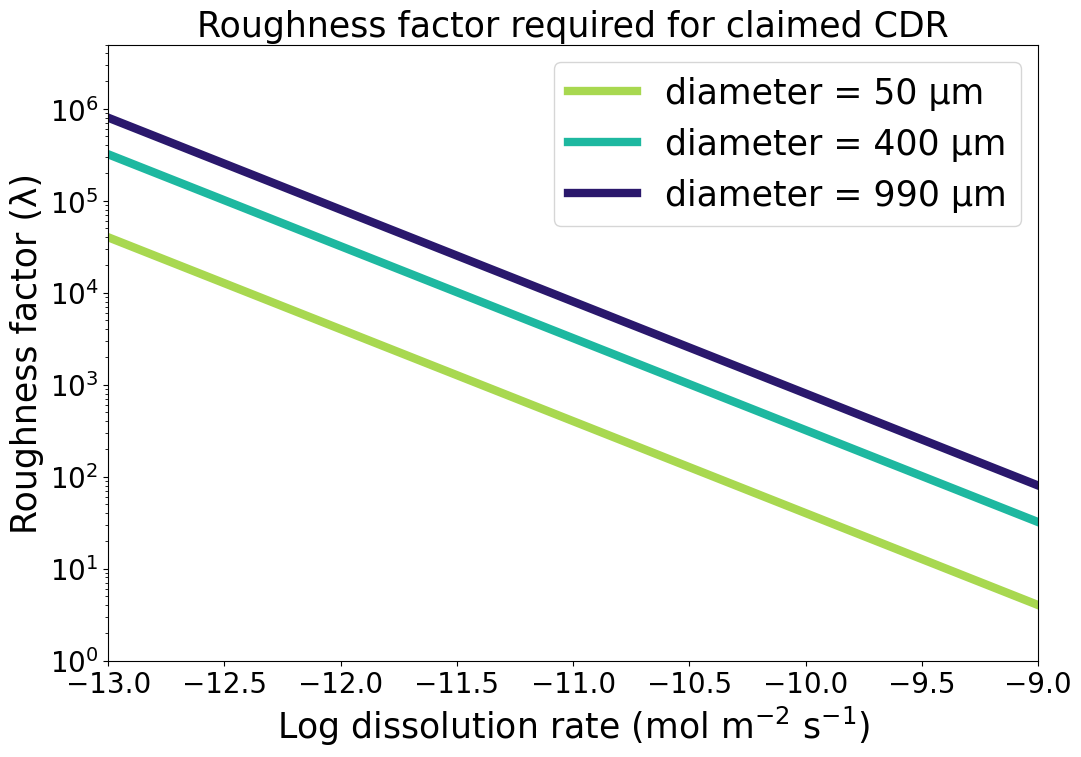

In [3]:
# --- Wx rate vs roughness
# 
# -------------------------------------
# [ aesthetics ]
# lines
diam_values = [50, 400, 990] # [microns]
lwd = 6
linecols = ["#a8d850", "#1eb8a0", "#2a186c"]
# fonts
fs_axlab = 25
fs_axtick = 20
fs_clab = 25
fs_leg = 25
# -------------------------------------
#

plt.figure(figsize=(12,8))
for diam in diam_values:
    tds = ds.sel(diameter_um=diam, method="nearest")
    plt.plot(
        tds['log_diss_rate'], tds['roughness_factor'], label=f"diameter = {diam:.0f} µm", 
        linewidth=lwd, color=linecols[diam_values.index(diam)]
    )
plt.yscale('log')
plt.ylim(1, 5e6)
plt.xlim(-13, -9)
plt.ylabel('Roughness factor (λ)', fontsize=fs_axlab)
plt.xlabel(r'Log dissolution rate (mol m$^{-2}$ s$^{-1}$)', fontsize=fs_axlab)
plt.xticks(fontsize=fs_axtick)
plt.yticks(fontsize=fs_axtick)
plt.legend(fontsize=fs_leg)
plt.title('Roughness factor required for claimed CDR', fontsize=fs_axlab)
plt.show()
plt.close()



## Rate versus SSA
Plot the weathering rate (X) versus the roughness factor (Y) for a given set of grain diameters

/var/folders/2r/w7zcr7vx4p5cr7n4d0b51f4c0000gn/T/ipykernel_13786/2120865615.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=fs_leg)


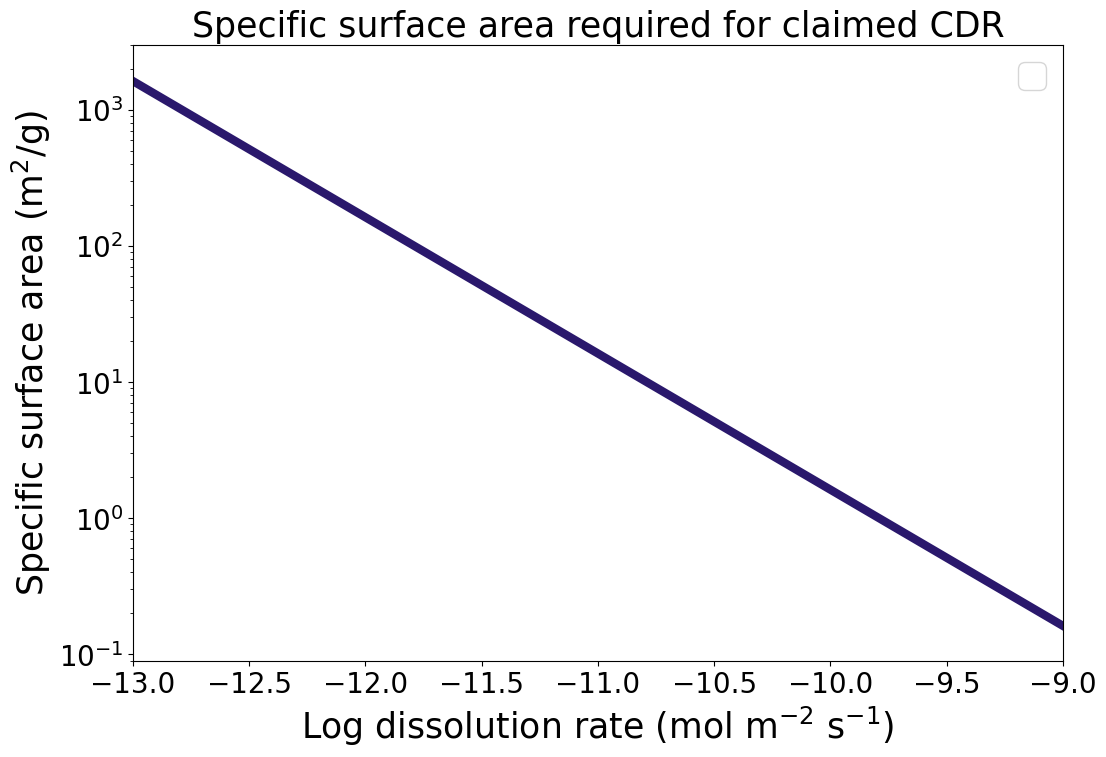

In [6]:
# --- Wx rate vs roughness
# 
# -------------------------------------
# [ aesthetics ]
# lines
lwd = 6
linecols = ["#a8d850", "#1eb8a0", "#2a186c"]
# fonts
fs_axlab = 25
fs_axtick = 20
fs_clab = 25
fs_leg = 25
# -------------------------------------
#
# --- pick diam (doesn't matter which because SSA is constant with diameter)
diam = 50 # [microns]

plt.figure(figsize=(12,8))
tds = ds.sel(diameter_um=diam, method="nearest")
plt.plot(
    tds['log_diss_rate'], tds['ssa'], 
    linewidth=lwd, color=linecols[2],
)
plt.yscale('log')
plt.ylim(9e-2, 3e3)
plt.xlim(-13, -9)
plt.ylabel(r'Specific surface area (m$^2$/g)', fontsize=fs_axlab)
plt.xlabel(r'Log dissolution rate (mol m$^{-2}$ s$^{-1}$)', fontsize=fs_axlab)
plt.xticks(fontsize=fs_axtick)
plt.yticks(fontsize=fs_axtick)
plt.legend(fontsize=fs_leg)
plt.title('Specific surface area required for claimed CDR', fontsize=fs_axlab)
plt.show()
plt.close()



## Geometric SSA vs diam

/var/folders/2r/w7zcr7vx4p5cr7n4d0b51f4c0000gn/T/ipykernel_13786/422445243.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=fs_leg)


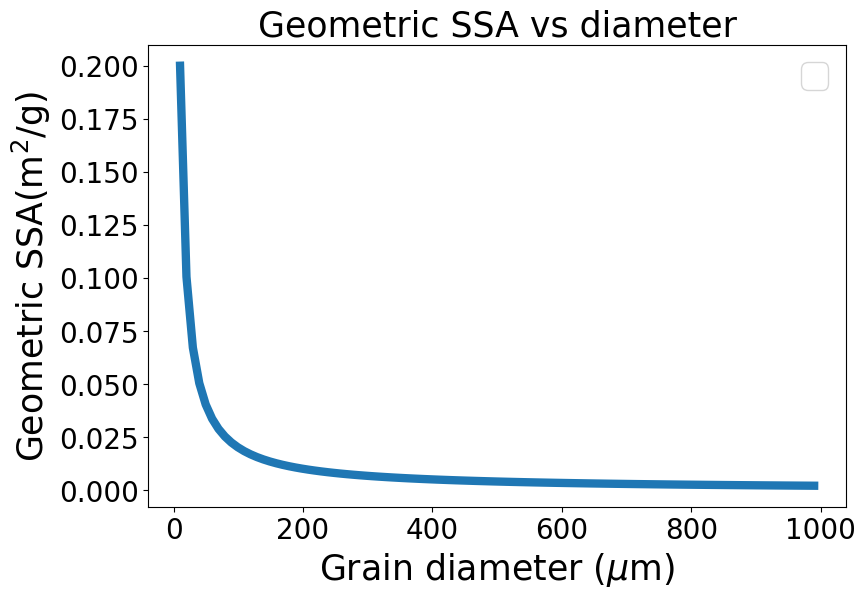

In [7]:
plt.figure(figsize=(9,6))
plt.plot(ds['diameter_um'], ds['geometric_ssa'], linewidth=lwd)
plt.ylabel(r'Geometric SSA(m$^2$/g)', fontsize=fs_axlab)
plt.xlabel(r'Grain diameter ($\mu$m)', fontsize=fs_axlab)
plt.xticks(fontsize=fs_axtick)
plt.yticks(fontsize=fs_axtick)
plt.legend(fontsize=fs_leg)
plt.title('Geometric SSA vs diameter', fontsize=fs_axlab)
plt.show()
plt.close()


### Quick plots

<a list of 4 text.Text objects>

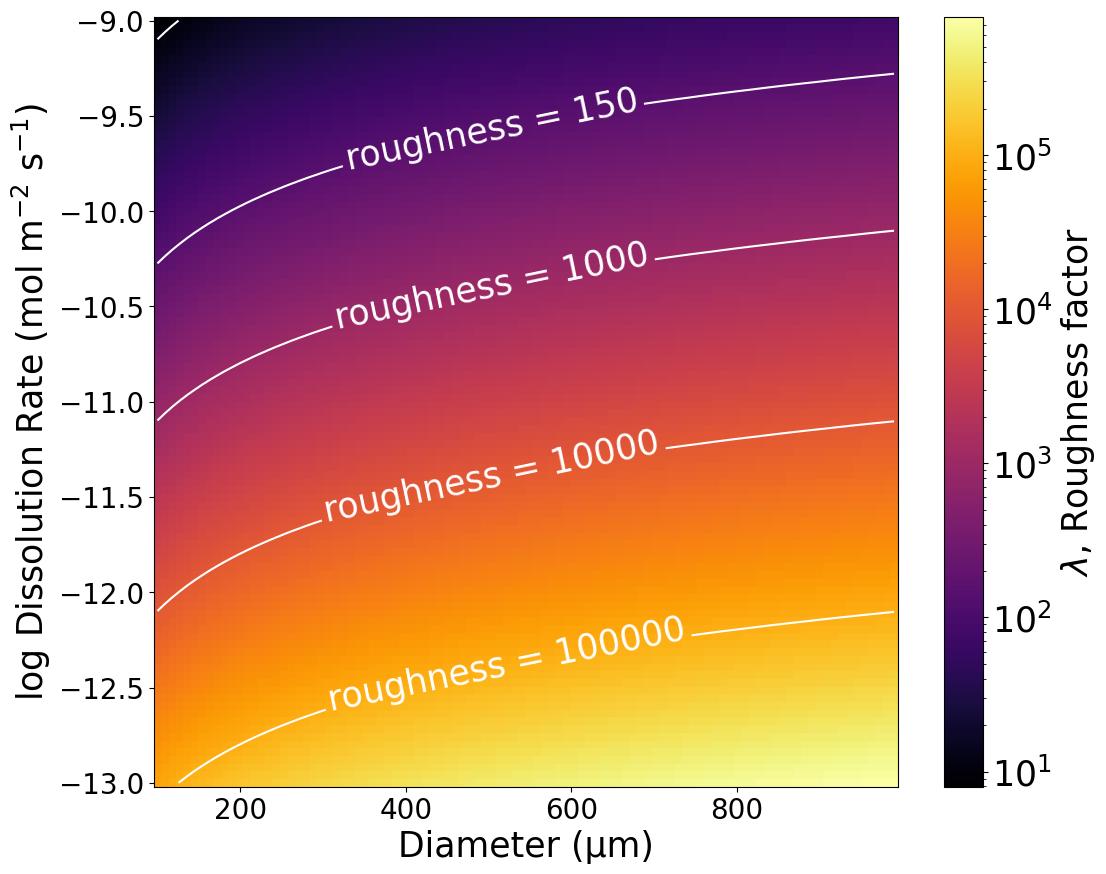

In [26]:
# --- roughness factor required for claimed CDR
# 
# -------------------------------------
# [ aesthetics ]
# fonts
fs_axlab = 25
fs_axtick = 20
fs_clab = 25
fs_leg = 25
# -------------------------------------
#
rf = ds.roughness_factor.where(ds.roughness_factor > 0)

plt.figure(figsize=(12,10))
# draw heatmap
mappable = rf.plot(
    x="diameter_um",
    y="log_diss_rate",
    norm=LogNorm(),
    cmap="inferno"
)
cbar = mappable.colorbar
cbar.set_label(r"$\lambda$, Roughness factor", fontsize=fs_leg)
cbar.ax.tick_params(labelsize=fs_leg)

# get the actual Axes
ax = plt.gca()

# draw contour
cs = ax.contour(
    ds["diameter_um"],
    ds["log_diss_rate"],
    rf,
    levels=[10, 150, 1000, 1e4, 1e5],
    colors="white",
    linewidths=1.5,
)
ax.set_xlabel("Diameter (µm)", fontsize=fs_axlab)
ax.set_ylabel(r"log Dissolution Rate (mol m$^{-2}$ s$^{-1}$)", fontsize=fs_axlab)
ax.tick_params(axis='both', labelsize=fs_axtick)
ax.clabel(cs, fmt="roughness = %d", fontsize=fs_clab)


In [ ]:
# ---